What all we have to do:

1) Predict the next word in a review sentence. (DL->RNN)
2) Predict sentiment or rating. (SUPERVISED ML)
3) Discover hidden customer behavior patterns. (UNSUPERVISED ML)

### **IMPORTING**

In [ ]:
!pip install gensim

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Flatten, InputLayer, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer

import nltk
import re

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

import gensim
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.sequence import pad_sequences

import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 52.3 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


### **Cleaning Data**

In [ ]:
df=pd.read_csv("/content/ecommerce_nlp_ml_dl_dataset_10000_UPDATED.csv")

In [ ]:
df.head(2)

,user_id,product_id,product_name,category,review_text,rating,review_length,sentiment_label,country,purchase_amount
0,U2170 !,P133 ! !,earbuds !,accessories,honestly speaking value for money !,4.827291,3.140782,negative,USA !,60273.641116
1,U1671 ! !,P177,smartwatch,gadgets !,this product is below expectations,1.182464,3.170094,neutral ! !,Canada,98214.443835


In [ ]:
df=df.drop("purchase_date", axis=1)

In [ ]:
df.isnull().sum()

,0
user_id,0
product_id,0
product_name,0
category,0
review_text,324
rating,1666
review_length,947
sentiment_label,552
country,0
purchase_amount,697


In [ ]:
df.loc[df["rating"].isna(),'rating'] = df["rating"].mean()
df["review_length"] = df["review_length"].fillna(df["purchase_amount"].mean())
df["purchase_amount"] = df["purchase_amount"].fillna(df["purchase_amount"].mean())

In [ ]:
df.head()

,user_id,product_id,product_name,category,review_text,rating,review_length,sentiment_label,country,purchase_amount
0,U2170 !,P133 ! !,earbuds !,accessories,honestly speaking value for money !,4.827291,3.140782,negative,USA !,60273.641116
1,U1671 ! !,P177,smartwatch,gadgets !,this product is below expectations,1.182464,3.170094,neutral ! !,Canada,98214.443835
2,U1357 ! !,P802,tablet ! !,gadgets !,overall my opinion is excellent for daily use,4.837949,8.547157,positive,Australia ! !,60273.641116
3,U1399 ! !,P410 ! !,mouse,accessories ! !,honestly speaking surprisingly good performance,3.009757,3.202779,neutral ! !,Canada ! !,60273.641116
4,U1664 !,P964 !,mouse,electronics,initially i thought excellent for daily use,-0.624306,6.888181,! !,UK !,91477.687391


In [ ]:
df.isnull().sum()

,0
user_id,0
product_id,0
product_name,0
category,0
review_text,324
rating,0
review_length,0
sentiment_label,552
country,0
purchase_amount,0


In [ ]:
df['review_text']=df['review_text'].fillna('missing review')
df['sentiment_label']=df['sentiment_label'].fillna('missing label')

In [ ]:
df.isnull().sum()

,0
user_id,0
product_id,0
product_name,0
category,0
review_text,0
rating,0
review_length,0
sentiment_label,0
country,0
purchase_amount,0


In [ ]:
df.head()

,user_id,product_id,product_name,category,review_text,rating,review_length,sentiment_label,country,purchase_amount
0,U2170 !,P133 ! !,earbuds !,accessories,honestly speaking value for money !,4.827291,3.140782,negative,USA !,60273.641116
1,U1671 ! !,P177,smartwatch,gadgets !,this product is below expectations,1.182464,3.170094,neutral ! !,Canada,98214.443835
2,U1357 ! !,P802,tablet ! !,gadgets !,overall my opinion is excellent for daily use,4.837949,8.547157,positive,Australia ! !,60273.641116
3,U1399 ! !,P410 ! !,mouse,accessories ! !,honestly speaking surprisingly good performance,3.009757,3.202779,neutral ! !,Canada ! !,60273.641116
4,U1664 !,P964 !,mouse,electronics,initially i thought excellent for daily use,-0.624306,6.888181,! !,UK !,91477.687391


### **NLP + SUPERVISED ML**

Apply **word2vec** to

  **1) category**
  **2) review_text**


---


Apply **tf-df** to

  **1) product_name**

In [ ]:
df.head()

,user_id,product_id,product_name,category,review_text,rating,review_length,sentiment_label,country,purchase_amount
0,U2170 !,P133 ! !,earbuds !,accessories,honestly speaking value for money !,4.827291,3.140782,negative,USA !,60273.641116
1,U1671 ! !,P177,smartwatch,gadgets !,this product is below expectations,1.182464,3.170094,neutral ! !,Canada,98214.443835
2,U1357 ! !,P802,tablet ! !,gadgets !,overall my opinion is excellent for daily use,4.837949,8.547157,positive,Australia ! !,60273.641116
3,U1399 ! !,P410 ! !,mouse,accessories ! !,honestly speaking surprisingly good performance,3.009757,3.202779,neutral ! !,Canada ! !,60273.641116
4,U1664 !,P964 !,mouse,electronics,initially i thought excellent for daily use,-0.624306,6.888181,! !,UK !,91477.687391


**FOR CATEGORY**

In [ ]:
corpus2=[]

for msg2 in df['category']:
  msg2=re.sub('[^a-zA-Z]',' ',msg2)
  msg2=msg2.lower()
  words2=msg2.split()
  words2 = [ps.stem(w2) for w2 in words2 if w2 not in stop_words]
  corpus2.append(words2)

wordtovec2=Word2Vec(sentences=corpus2, vector_size=100, window=5, min_count=1, sg=1, epochs=10)


def word2vec2(line2,model):
  seq2=[]
  for words2 in line2:
    if words2 in model.wv:
      seq2.append(model.wv[words2])
  return seq2

x_sequence2=[word2vec2(line2,wordtovec2) for line2 in corpus2]
x2_pad=pad_sequences(x_sequence2,maxlen=50, dtype="float32", padding="post", truncating="post")

In [ ]:
df["category_w2v"] = list(x2_pad)

**FOR PRODUCT NAME**

In [ ]:
corpus=[]

for msg3 in df['product_name']:
  msg=re.sub('[^a-zA-Z]',' ',msg3)
  msg3=msg3.lower()
  words3=msg3.split()
  words3 = [ps.stem(w3) for w3 in words3 if w3 not in stop_words]
  corpus.append(words3)

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer()
tf=tfidf.fit_transform(df['product_name'])

In [ ]:
tf.shape

(10000, 9)

In [ ]:
df["product_tfidf"] = list(tf.toarray())

**FOR REVIEW**

In [ ]:
del max

corpus = []

for msg in df['review_text'].dropna():
    msg = re.sub('[^a-zA-Z]', ' ', msg)
    msg = msg.lower()
    words = msg.split()
    words = [ps.stem(w) for w in words if w not in stop_words]
    corpus.append(' '.join(words))

tokenizer = Tokenizer()
tokenizer.fit_on_texts(corpus)

vocab_size = len(tokenizer.word_index) + 1

input_sequences = []

for line in corpus:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i+1])

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len)

X_lm = input_sequences[:, :-1]
y_lm = input_sequences[:, -1]

In [ ]:
model = Sequential()
model.add(Embedding(vocab_size, 10, input_length=max_len-1))
model.add(LSTM(64))
model.add(Dense(vocab_size, activation="softmax"))

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

model.fit(X_lm, y_lm, epochs=10, verbose=0)

seed_text = "this product is"
next_words = 2

for _ in range(next_words):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_len - 1)
    predicted_index = model.predict(token_list, verbose=0).argmax()
    seed_text += " " + tokenizer.index_word[predicted_index]

print("Predicted text:", seed_text)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Predicted text: this product is valu money


**FOR USER ID, PRODUCT ID, LABEL & COUNTRY**

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['sentiment_label']=le.fit_transform(df['sentiment_label'])
df['country']=le.fit_transform(df['country'])
df['user_id']=le.fit_transform(df['user_id'])
df['product_id']=le.fit_transform(df['product_id'])

max = (df['country'].nunique() + df['user_id'].nunique() + df['product_id'].nunique() + df['sentiment_label'].nunique())

input_len = 3

model = Sequential()
model.add(Embedding(input_dim=max, output_dim=200, input_length=input_len))
model.add(LSTM(128))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
#LOAD DATA
from sklearn.feature_extraction.text import TfidfVectorizer
tf=TfidfVectorizer()

X_review_text=tf.fit_transform(df['review_text'])
df['X_review_text']=list(X_review_text.toarray())
X_review_text2=np.stack(df['X_review_text'].values)
X_category = np.stack(df['category_w2v'].values).reshape(len(df), -1)
X_product  = np.stack(df['product_tfidf'].values)
X_numeric  = df[['rating', 'review_length', 'country']].values

x = np.concatenate([X_category, X_product, X_numeric, X_review_text2], axis=1)
y = df['sentiment_label'].values

#CHOOSE MODEL
model=LogisticRegression()

#SPLIT
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

#STANDARAD SCALAR
std=StandardScaler()
x_train_std=std.fit_transform(x_train)
x_test_std=std.transform(x_test)

#CV
kf=StratifiedKFold(n_splits=5)
y_pred_train=cross_val_predict(model, x_train_std, y_train, cv=kf)

#TRAIN
model.fit(x_train_std, y_train)

y_pred_test=model.predict(x_test_std)
print(y_pred_test)

#EVALUATE
acc_train=accuracy_score(y_train,y_pred_train)
acc_test=accuracy_score(y_test,y_pred_test)

prec_sc_train=precision_score(y_train,y_pred_train, average='macro')
prec_cv_test=precision_score(y_test,y_pred_test, average='macro')

recall_train=recall_score(y_train,y_pred_train, average='macro')
recall_test=recall_score(y_test,y_pred_test, average='macro')

clas_train=classification_report(y_train,y_pred_train)
clas_test=classification_report(y_test,y_pred_test)

conf_train=confusion_matrix(y_train,y_pred_train)
conf_test=confusion_matrix(y_test,y_pred_test)

print(acc_train)
print(acc_test)
print(prec_sc_train)
print(prec_cv_test)
print(recall_train)
print(recall_test)
print(clas_train)
print(clas_test)
print(conf_train)
print(conf_test)

[10  8  8 ...  9 10  4]
0.09728571428571428
0.097
0.07998118857382928
0.07328841890228617
0.08542044667476263
0.08644560523931476
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       345
           1       0.00      0.00      0.00       332
           2       0.11      0.00      0.01       391
           3       0.11      0.13      0.12       634
           4       0.08      0.07      0.07       627
           5       0.07      0.04      0.05       640
           6       0.09      0.13      0.11       686
           7       0.09      0.09      0.09       667
           8       0.11      0.14      0.12       665
           9       0.10      0.12      0.11       672
          10       0.11      0.20      0.14       691
          11       0.09      0.10      0.10       650

    accuracy                           0.10      7000
   macro avg       0.08      0.09      0.08      7000
weighted avg       0.09      0.10      0.09      7000

   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

# **UNSUPERVISED ML**

## **STEP 1**

In [ ]:
df.head(2)

,user_id,product_id,product_name,category,review_text,rating,review_length,sentiment_label,country,purchase_amount,category_w2v,product_tfidf
0,3147,99,earbuds !,accessories,honestly speaking value for money !,4.827291,3.140782,3,16,60273.641116,"[[9.456396e-05, 0.0030773198, -0.006812645, -0...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
1,1797,228,smartwatch,gadgets !,this product is below expectations,1.182464,3.170094,8,3,98214.443835,"[[-0.00053622725, 0.00023643136, 0.0051033497,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"


In [ ]:
x_p=np.vstack(df['product_tfidf'].values)
country = df['country'].values.reshape(-1, 1)
x = np.concatenate([x_p, X_category, country], axis=1)

In [ ]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
model=DBSCAN(eps=0.5, min_samples=5)

std=StandardScaler()
x_std=std.fit_transform(x)

labels=model.fit_predict(x_std)

df['clusters']=labels

ss=silhouette_score(x_std,labels)

print(ss)

0.7543145206806517


In [ ]:
mask = labels != -1
silhouette_score(x_std[mask], labels[mask])

np.float64(0.7543145206806517)

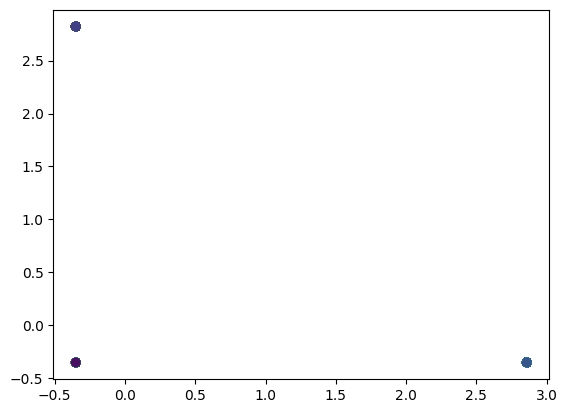

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(x_std[:, 0], x_std[:, 1], c=labels)

In [ ]:
df.head(2)

,user_id,product_id,product_name,category,review_text,rating,review_length,sentiment_label,country,purchase_amount,category_w2v,product_tfidf,clusters
0,3147,99,earbuds !,accessories,honestly speaking value for money !,4.827291,3.140782,3,16,60273.641116,"[[9.456396e-05, 0.0030773198, -0.006812645, -0...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",0
1,1797,228,smartwatch,gadgets !,this product is below expectations,1.182464,3.170094,8,3,98214.443835,"[[-0.00053622725, 0.00023643136, 0.0051033497,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]",1


In [ ]:
cluster_counts = df["clusters"].value_counts().sort_index()
print(cluster_counts)

clusters
0     388
1     395
2     396
3     353
4     403
5     361
6     352
7     363
8     353
9     386
10    357
11    354
12    364
13    373
14    359
15    397
16    342
17    342
18    365
19    366
20    382
21    391
22    364
23    370
24    367
25    371
26    386
Name: count, dtype: int64


In [ ]:
cluster_percentage = df["clusters"].value_counts(normalize=True) * 100
print(cluster_percentage)

clusters
4     4.03
15    3.97
2     3.96
1     3.95
21    3.91
0     3.88
9     3.86
26    3.86
20    3.82
13    3.73
25    3.71
23    3.70
24    3.67
19    3.66
18    3.65
12    3.64
22    3.64
7     3.63
5     3.61
14    3.59
10    3.57
11    3.54
3     3.53
8     3.53
6     3.52
17    3.42
16    3.42
Name: proportion, dtype: float64
